# 🎧 SoundSense AI — Intelligent Environmental Sound Recognition
Multi-label environmental sound event classification on **FSD50K**, using a CNN → BiLSTM → Attention architecture.

**What changed in this version compared to the first pass:**
- Added `pos_weight` to the loss to directly counter class imbalance (the biggest driver of the Macro F1 / mAP gap).
- Added SpecAugment (frequency + time masking) — only applied during training.
- Added per-sample Mel normalization, gradient clipping, and mixed-precision (AMP) training.
- Checkpointing now saves the model with the **best validation mAP**, not the lowest loss — mAP is the metric that actually matters for multi-label ranking quality.
- Fixed notebook ordering: the model is fully defined *before* training ever runs.
- Rewrote the model as a proper `nn.Module` class instead of a `ModuleDict` + free function — cleaner and easier to extend later.
- Added a sliding-window inference function that handles real-world audio files of any length (not just 5s clips), for the deployment/API stage.

**A note on audio duration (5s vs 10s):** FSD50K clips average roughly 7-8 seconds, and doubling the clip length roughly doubles compute per epoch. Given a limited Kaggle GPU quota, that budget is better spent on more epochs with the changes above — which directly target the diagnosed problem (imbalance) — rather than on longer clips, which don't. `AUDIO_DURATION` is still a config variable below if you want to try 10s later as a separate, isolated experiment once this baseline is stable.


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchaudio

from sklearn.metrics import f1_score, precision_score, recall_score, average_precision_score
from collections import Counter

import os
import json
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

print("PyTorch version:", torch.__version__)
print("Torchaudio version:", torchaudio.__version__)
print("Librosa version:", librosa.__version__)


Device: cuda
CUDA available: True
GPU name: Tesla T4
PyTorch version: 2.10.0+cu128
Torchaudio version: 2.10.0+cu128
Librosa version: 0.11.0


## Configuration
All tunable settings live here so nothing is hardcoded deeper in the notebook.

In [2]:
SAMPLE_RATE   = 16000
AUDIO_DURATION = 5.0      
N_MELS        = 128
N_FFT         = 1024
HOP_LENGTH    = 512

BATCH_SIZE    = 32
NUM_WORKERS   = 2

CNN_CHANNELS  = 64        
LSTM_HIDDEN   = 128
LSTM_LAYERS   = 2
DROPOUT       = 0.3

LEARNING_RATE = 1e-4
WEIGHT_DECAY  = 1e-5
NUM_EPOCHS    = 40
PATIENCE      = 8         

MODEL_PATH    = "soundsense_best.pth"
CONFIG_PATH   = "config.json"
CLASSES_PATH  = "classes.json"
THRESHOLDS_PATH = "thresholds.json"


## Loading Dataset

In [3]:
DATASET_ROOT = "/kaggle/input/datasets/yousirui1/fsd50k/fsd50k"

GT_PATH        = os.path.join(DATASET_ROOT, "FSD50K.ground_truth")
DEV_AUDIO_PATH = os.path.join(DATASET_ROOT, "FSD50K.dev_audio_16k")
EVAL_AUDIO_PATH = os.path.join(DATASET_ROOT, "FSD50K.eval_audio_16k")

print(os.listdir(DATASET_ROOT))

dev_df   = pd.read_csv(os.path.join(GT_PATH, "dev.csv"))
eval_df  = pd.read_csv(os.path.join(GT_PATH, "eval.csv"))
vocab_df = pd.read_csv(os.path.join(GT_PATH, "vocabulary.csv"), header=None, names=["index", "label", "mid"])

['FSD50K.ground_truth', 'FSD50K.metadata', 'FSD50K.dev_audio_16k', 'FSD50K.doc', 'FSD50K.eval_audio', 'FSD50K.eval_audio_16k']


In [4]:
print("dev shape:", dev_df.shape)
print("eval shape:", eval_df.shape)
print("vocab shape:", vocab_df.shape)

dev_df.head()

dev shape: (40966, 4)
eval shape: (10231, 3)
vocab shape: (200, 3)


,fname,labels,mids,split
0,64760,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",train
1,16399,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",train
2,16401,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",train
3,16402,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",train
4,16404,"Electric_guitar,Guitar,Plucked_string_instrume...","/m/02sgy,/m/0342h,/m/0fx80y,/m/04szw,/m/04rlf",train


## Exploratory Data Analysis (EDA)

In [5]:
dev_df["label_list"] = dev_df["labels"].apply(lambda x: x.split(","))

all_labels = [label for sublist in dev_df["label_list"] for label in sublist]
label_counts_df = (pd.DataFrame(Counter(all_labels).items(), columns=["label", "count"])
                    .sort_values("count", ascending=False))

print("Total dev clips:", len(dev_df))
print("Number of classes used in dev:", len(set(all_labels)))
print("Imbalance ratio (max/min):", label_counts_df["count"].max() / label_counts_df["count"].min())
print(dev_df["split"].value_counts())


Total dev clips: 40966
Number of classes used in dev: 200
Imbalance ratio (max/min): 250.33333333333334
split
train    36796
val       4170
Name: count, dtype: int64


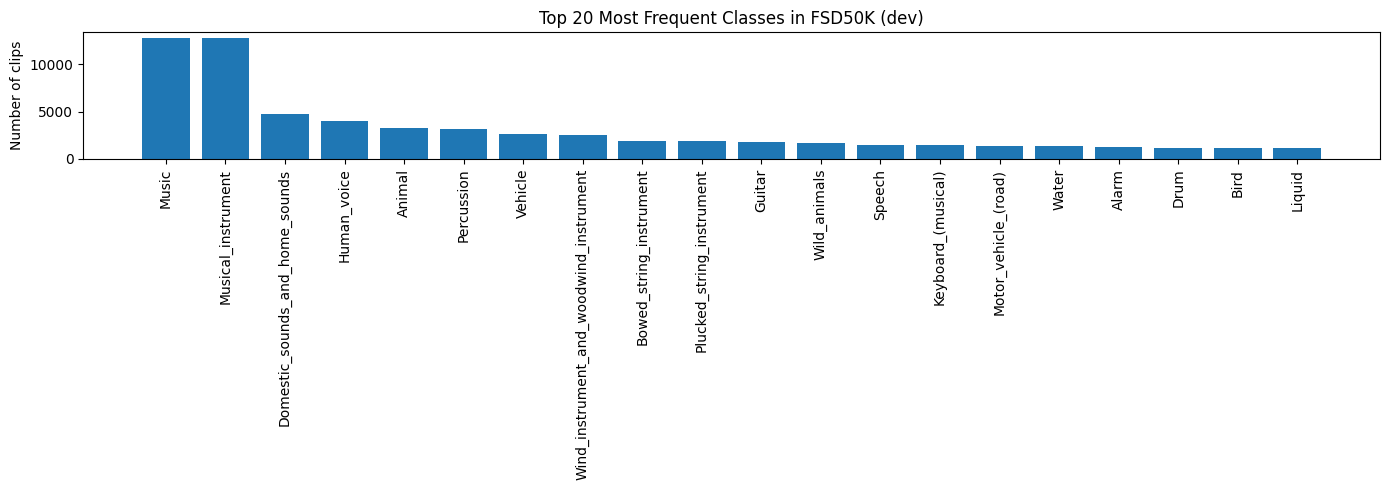

In [6]:
plt.figure(figsize=(14, 5))
plt.bar(label_counts_df["label"].head(20), label_counts_df["count"].head(20))
plt.xticks(rotation=90)
plt.title("Top 20 Most Frequent Classes in FSD50K (dev)")
plt.ylabel("Number of clips")
plt.tight_layout()
plt.show()


Mean labels per clip: 2.789410730849973
Max labels in a single clip: 18


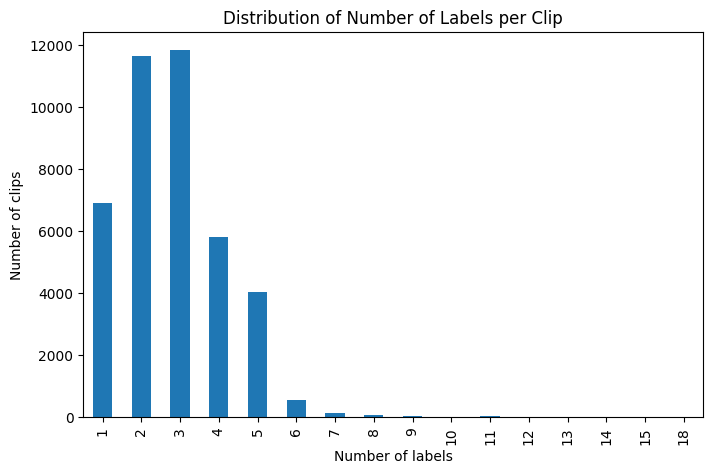

In [7]:
dev_df["num_labels"] = dev_df["label_list"].apply(len)
print("Mean labels per clip:", dev_df["num_labels"].mean())
print("Max labels in a single clip:", dev_df["num_labels"].max())

plt.figure(figsize=(8, 5))
dev_df["num_labels"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Number of Labels per Clip")
plt.xlabel("Number of labels")
plt.ylabel("Number of clips")
plt.show()


## Audio Analysis

Unique sample rates: {16000}
Mean duration (s): 6.8811278125 | Median: 4.240375


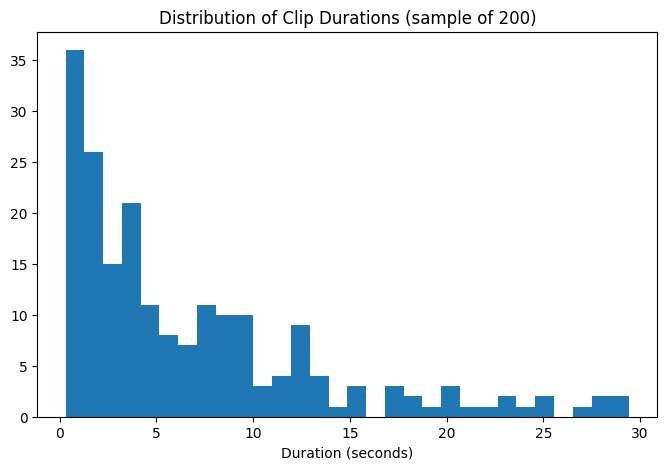

In [8]:
sample_fnames = dev_df["fname"].sample(200, random_state=42).tolist()
durations, sample_rates = [], []

for fname in sample_fnames:
    info = sf.info(os.path.join(DEV_AUDIO_PATH, f"{fname}.wav"))
    durations.append(info.duration)
    sample_rates.append(info.samplerate)

print("Unique sample rates:", set(sample_rates))
print("Mean duration (s):", np.mean(durations), "| Median:", np.median(durations))

plt.figure(figsize=(8, 5))
plt.hist(durations, bins=30)
plt.title("Distribution of Clip Durations (sample of 200)")
plt.xlabel("Duration (seconds)")
plt.show()


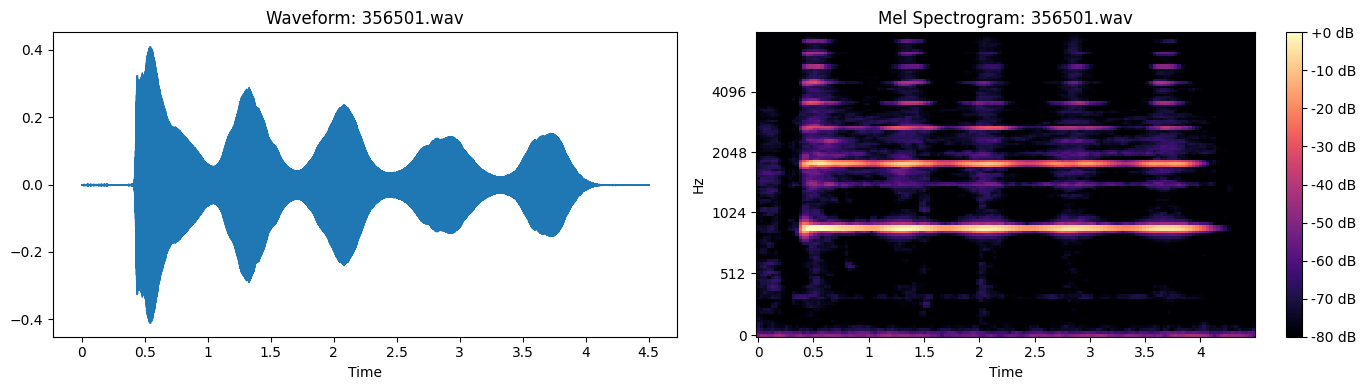

In [9]:
sample_file = os.path.join(DEV_AUDIO_PATH, f"{sample_fnames[0]}.wav")
y, sr = librosa.load(sample_file, sr=None)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
librosa.display.waveshow(y, sr=sr, ax=axes[0])
axes[0].set_title(f"Waveform: {sample_fnames[0]}.wav")

mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
img = librosa.display.specshow(mel_spec_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[1])
axes[1].set_title(f"Mel Spectrogram: {sample_fnames[0]}.wav")
fig.colorbar(img, ax=axes[1], format="%+2.0f dB")
plt.tight_layout()
plt.show()


## Label Encoding

In [10]:
label_to_idx = {row["label"]: row["index"] for _, row in vocab_df.iterrows()}
idx_to_label = {v: k for k, v in label_to_idx.items()}
NUM_CLASSES = len(label_to_idx)
print("Number of classes:", NUM_CLASSES)

def encode_labels(label_list):
    vec = np.zeros(NUM_CLASSES, dtype=np.float32)
    for label in label_list:
        vec[label_to_idx[label]] = 1.0
    return vec

train_df = dev_df[dev_df["split"] == "train"].reset_index(drop=True)
val_df   = dev_df[dev_df["split"] == "val"].reset_index(drop=True)
print("Train clips:", len(train_df), "| Val clips:", len(val_df))


Number of classes: 200
Train clips: 36796 | Val clips: 4170


## Dataset Pipeline
Adds per-sample normalization (stabilizes training) and SpecAugment (frequency + time masking, training only) on top of the original load → mono → resample/crop/pad → Mel Spectrogram pipeline.

In [11]:
class FSD50KDataset(Dataset):
    def __init__(self, df, audio_dir, sample_rate=SAMPLE_RATE, duration=AUDIO_DURATION,
                 n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH,
                 train=True, use_specaugment=True):
        self.df = df.reset_index(drop=True)
        self.audio_dir = audio_dir
        self.sample_rate = sample_rate
        self.num_samples = int(sample_rate * duration)
        self.train = train
        self.use_specaugment = use_specaugment and train

        self.mel_transform = torchaudio.transforms.MelSpectrogram(
            sample_rate=sample_rate, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
        )
        self.db_transform = torchaudio.transforms.AmplitudeToDB()

        self.freq_mask = torchaudio.transforms.FrequencyMasking(freq_mask_param=16)
        self.time_mask = torchaudio.transforms.TimeMasking(time_mask_param=24)

    def __len__(self):
        return len(self.df)

    def _load_and_fix_length(self, file_path):
        waveform, sr = torchaudio.load(file_path)
        waveform = waveform.mean(dim=0)  # mono

        if waveform.shape[0] < self.num_samples:
            pad_amount = self.num_samples - waveform.shape[0]
            waveform = torch.nn.functional.pad(waveform, (0, pad_amount))
        elif waveform.shape[0] > self.num_samples:
            max_start = waveform.shape[0] - self.num_samples
            if self.train:
                start = torch.randint(0, max_start + 1, (1,)).item()  # random crop = light augmentation
            else:
                start = max_start // 2  # center crop, deterministic
            waveform = waveform[start:start + self.num_samples]

        return waveform

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        file_path = os.path.join(self.audio_dir, f"{row['fname']}.wav")

        waveform = self._load_and_fix_length(file_path)
        mel_spec_db = self.db_transform(self.mel_transform(waveform))

        # Per-sample normalization (mean/std) — helps training stability a lot
        mel_spec_db = (mel_spec_db - mel_spec_db.mean()) / (mel_spec_db.std() + 1e-6)

        if self.use_specaugment:
            mel_spec_db = self.freq_mask(mel_spec_db)
            mel_spec_db = self.time_mask(mel_spec_db)

        label_vec = encode_labels(row["label_list"])
        return mel_spec_db, torch.tensor(label_vec)


train_dataset = FSD50KDataset(train_df, DEV_AUDIO_PATH, train=True,  use_specaugment=True)
val_dataset   = FSD50KDataset(val_df,   DEV_AUDIO_PATH, train=False, use_specaugment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

sample_spec, sample_label = train_dataset[0]
print("Spectrogram shape:", sample_spec.shape)
print("Label vector shape:", sample_label.shape, "| Active labels:", sample_label.sum().item())


Spectrogram shape: torch.Size([128, 157])
Label vector shape: torch.Size([200]) | Active labels: 5.0


## Model — CNN → BiLSTM → Attention
Rewritten as a single `nn.Module` (instead of a `ModuleDict` + separate forward function) — this is the standard, clean way to define a PyTorch model and makes the architecture easier to read, save, and extend.

In [12]:
class SoundSenseModel(nn.Module):
    def __init__(self, num_classes, n_mels=N_MELS, cnn_channels=CNN_CHANNELS,
                 lstm_hidden=LSTM_HIDDEN, lstm_layers=LSTM_LAYERS, dropout=DROPOUT):
        super().__init__()

        self.conv_block = nn.Sequential(
            nn.Conv2d(1, cnn_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(cnn_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(cnn_channels, cnn_channels * 2, kernel_size=3, padding=1),
            nn.BatchNorm2d(cnn_channels * 2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(cnn_channels * 2, cnn_channels * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(cnn_channels * 4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        cnn_out_freq = n_mels // 8          # 3x pooling by 2
        cnn_out_channels = cnn_channels * 4
        lstm_input_size = cnn_out_channels * cnn_out_freq

        self.lstm = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=lstm_hidden,
            num_layers=lstm_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if lstm_layers > 1 else 0.0,
        )

        self.attn_linear = nn.Linear(lstm_hidden * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_hidden * 2, num_classes)

    def forward(self, x):
        # x: (batch, n_mels, time)
        x = x.unsqueeze(1)                     
        x = self.conv_block(x)                  

        batch_size, channels, freq, time = x.shape
        x = x.permute(0, 3, 1, 2).reshape(batch_size, time, channels * freq)  

        lstm_out, _ = self.lstm(x)           

        attn_weights = torch.softmax(self.attn_linear(lstm_out), dim=1)     
        context = torch.sum(attn_weights * lstm_out, dim=1)                 

        logits = self.fc(self.dropout(context)) 
        return logits


model = SoundSenseModel(num_classes=NUM_CLASSES).to(device)

# Shape test — done here, BEFORE training, never after
sample_spec, _ = train_dataset[0]
sample_spec = sample_spec.unsqueeze(0).to(device)
with torch.no_grad():
    test_output = model(sample_spec)

print("Input shape:", sample_spec.shape)
print("Output (logits) shape:", test_output.shape)
print("Total trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Input shape: torch.Size([1, 128, 157])
Output (logits) shape: torch.Size([1, 200])
Total trainable parameters: 5144905


## Loss, Optimizer, Scheduler
`pos_weight` is computed directly from the training set's class frequencies and clipped to a reasonable range (1-20) so rare-class weighting doesn't destabilize the loss. This is the single change most directly aimed at the imbalance problem seen in the first run.

In [13]:
def calculate_pos_weights(df, label_to_idx, num_classes, clip_min=1.0, clip_max=20.0):
    label_matrix = np.stack(df["label_list"].apply(encode_labels).values)
    pos_counts = label_matrix.sum(axis=0)
    neg_counts = len(df) - pos_counts
    weights = neg_counts / np.clip(pos_counts, 1, None)
    weights = np.clip(weights, clip_min, clip_max)
    return torch.tensor(weights, dtype=torch.float32)

pos_weight = calculate_pos_weights(train_df, label_to_idx, NUM_CLASSES).to(device)
print("pos_weight range:", pos_weight.min().item(), "-", pos_weight.max().item())

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)
scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())


pos_weight range: 2.1693367958068848 - 20.0


## Training

In [14]:
def run_train_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss = 0.0
    for specs, labels in loader:
        specs, labels = specs.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(specs)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)  # avoids loss spikes from pos_weight
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * specs.size(0)
    return total_loss / len(loader.dataset)


def run_val_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_probs, all_labels = [], []

    with torch.no_grad():
        for specs, labels in loader:
            specs, labels = specs.to(device), labels.to(device)
            with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                logits = model(specs)
                loss = criterion(logits, labels)
            total_loss += loss.item() * specs.size(0)

            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    mean_ap = average_precision_score(all_labels, all_probs, average="macro")

    return total_loss / len(loader.dataset), mean_ap


In [15]:
best_val_map = 0.0
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "val_map": []}

for epoch in range(NUM_EPOCHS):
    train_loss = run_train_epoch(model, train_loader, criterion, optimizer, scaler)
    val_loss, val_map = run_val_epoch(model, val_loader, criterion)
    scheduler.step(val_map)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_map"].append(val_map)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val mAP: {val_map:.4f}")

    if val_map > best_val_map:
        best_val_map = val_map
        epochs_no_improve = 0
        torch.save(model.state_dict(), MODEL_PATH)
        print(f"  -> mAP improved ({val_map:.4f}), model saved.")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epoch(s).")

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}.")
        break

print(f"\nBest validation mAP: {best_val_map:.4f}")


Epoch 1/40 | Train Loss: 0.4313 | Val Loss: 0.4632 | Val mAP: 0.0775
  -> mAP improved (0.0775), model saved.
Epoch 2/40 | Train Loss: 0.3411 | Val Loss: 0.4123 | Val mAP: 0.1096
  -> mAP improved (0.1096), model saved.
Epoch 3/40 | Train Loss: 0.3051 | Val Loss: 0.4025 | Val mAP: 0.1301
  -> mAP improved (0.1301), model saved.
Epoch 4/40 | Train Loss: 0.2823 | Val Loss: 0.3850 | Val mAP: 0.1484
  -> mAP improved (0.1484), model saved.
Epoch 5/40 | Train Loss: 0.2645 | Val Loss: 0.3642 | Val mAP: 0.1768
  -> mAP improved (0.1768), model saved.
Epoch 6/40 | Train Loss: 0.2514 | Val Loss: 0.3447 | Val mAP: 0.2028
  -> mAP improved (0.2028), model saved.
Epoch 7/40 | Train Loss: 0.2398 | Val Loss: 0.3409 | Val mAP: 0.2049
  -> mAP improved (0.2049), model saved.
Epoch 8/40 | Train Loss: 0.2308 | Val Loss: 0.3300 | Val mAP: 0.2201
  -> mAP improved (0.2201), model saved.
Epoch 9/40 | Train Loss: 0.2225 | Val Loss: 0.3282 | Val mAP: 0.2296
  -> mAP improved (0.2296), model saved.
Epoch 10/4

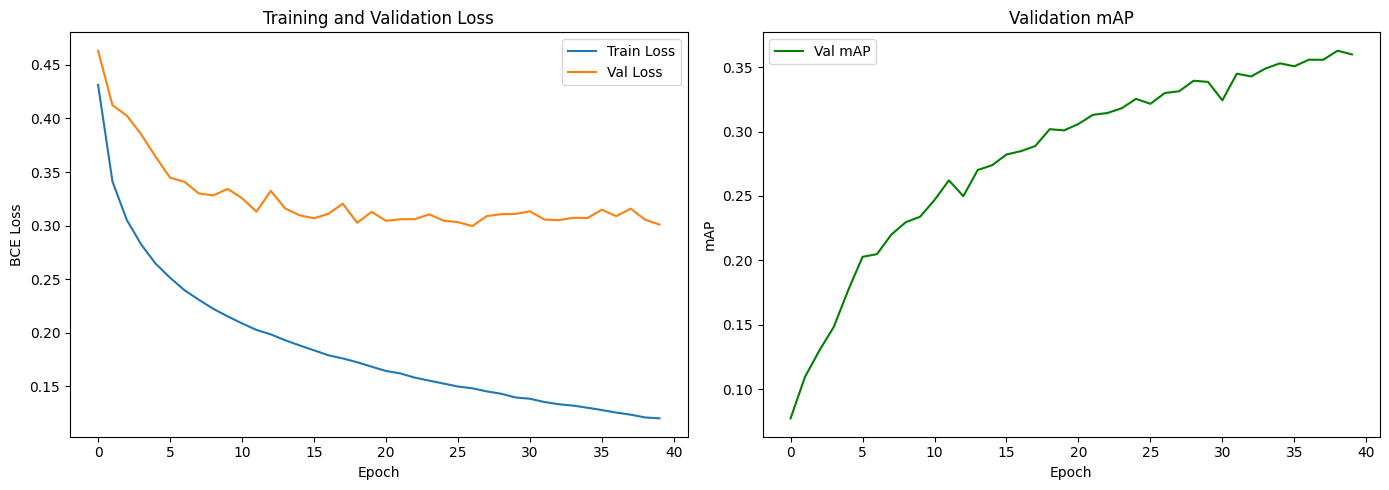

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE Loss"); axes[0].legend()
axes[0].set_title("Training and Validation Loss")

axes[1].plot(history["val_map"], label="Val mAP", color="green")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("mAP"); axes[1].legend()
axes[1].set_title("Validation mAP")
plt.tight_layout()
plt.show()


## Evaluation — load the best checkpoint and score it

In [17]:
model.load_state_dict(torch.load(MODEL_PATH))
model.eval()

all_probs, all_labels = [], []
with torch.no_grad():
    for specs, labels in val_loader:
        specs = specs.to(device)
        probs = torch.sigmoid(model(specs))
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)
print("Predictions shape:", all_probs.shape)


Predictions shape: (4170, 200)


In [18]:
DEFAULT_THRESHOLD = 0.5
preds_binary = (all_probs >= DEFAULT_THRESHOLD).astype(int)

micro_f1 = f1_score(all_labels, preds_binary, average="micro", zero_division=0)
macro_f1 = f1_score(all_labels, preds_binary, average="macro", zero_division=0)
micro_precision = precision_score(all_labels, preds_binary, average="micro", zero_division=0)
micro_recall = recall_score(all_labels, preds_binary, average="micro", zero_division=0)
mean_ap = average_precision_score(all_labels, all_probs, average="macro")

print(f"Micro F1: {micro_f1:.4f}")
print(f"Macro F1: {macro_f1:.4f}")
print(f"Micro Precision: {micro_precision:.4f}")
print(f"Micro Recall: {micro_recall:.4f}")
print(f"Mean Average Precision (mAP): {mean_ap:.4f}")


Micro F1: 0.4192
Macro F1: 0.3220
Micro Precision: 0.3033
Micro Recall: 0.6787
Mean Average Precision (mAP): 0.3633


## Per-Class Threshold Optimization

In [19]:
best_thresholds = np.full(NUM_CLASSES, 0.5)
per_class_f1_at_best = np.zeros(NUM_CLASSES)
candidate_thresholds = np.arange(0.1, 0.9, 0.05)

for class_idx in range(NUM_CLASSES):
    y_true_c = all_labels[:, class_idx]
    if y_true_c.sum() == 0:
        continue  

    best_f1, best_t = 0.0, 0.5
    for t in candidate_thresholds:
        y_pred_c = (all_probs[:, class_idx] >= t).astype(int)
        f1 = f1_score(y_true_c, y_pred_c, zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t

    best_thresholds[class_idx] = best_t
    per_class_f1_at_best[class_idx] = best_f1

preds_optimized = (all_probs >= best_thresholds).astype(int)
micro_f1_opt = f1_score(all_labels, preds_optimized, average="micro", zero_division=0)
macro_f1_opt = f1_score(all_labels, preds_optimized, average="macro", zero_division=0)

print(f"Micro F1 (optimized thresholds): {micro_f1_opt:.4f}")
print(f"Macro F1 (optimized thresholds): {macro_f1_opt:.4f}")
print(f"Improvement over default 0.5 threshold: {macro_f1_opt - macro_f1:.4f} (macro F1)")


Micro F1 (optimized thresholds): 0.5246
Macro F1 (optimized thresholds): 0.4091
Improvement over default 0.5 threshold: 0.0871 (macro F1)


In [20]:
per_class_ap = average_precision_score(all_labels, all_probs, average=None)
class_perf_df = pd.DataFrame({
    "class": [idx_to_label[i] for i in range(NUM_CLASSES)],
    "AP": per_class_ap,
    "support": all_labels.sum(axis=0),
}).sort_values("AP")

print("Worst 10 performing classes:")
print(class_perf_df.head(10))
print("\nBest 10 performing classes:")
print(class_perf_df.tail(10))


Worst 10 performing classes:
                          class        AP  support
173                        Tick  0.009489     10.0
136            Ratchet_and_pawl  0.015592      8.0
1                     Accordion  0.028735      6.0
55       Cupboard_open_or_close  0.032973     16.0
124  Packing_tape_and_duct_tape  0.055026     10.0
130                     Printer  0.061489     15.0
137                      Rattle  0.064407     40.0
153                  Skateboard  0.064701     11.0
152                       Siren  0.067919     12.0
146                     Screech  0.074525     18.0

Best 10 performing classes:
                      class        AP  support
7                      Bark  0.714981     62.0
101             Human_voice  0.720620    355.0
22   Burping_and_eructation  0.739397     33.0
45                  Cowbell  0.753303     24.0
100     Human_group_actions  0.763277    141.0
6                  Applause  0.766394     72.0
125              Percussion  0.775944    421.0
57   

## Save the Final Model for Deployment
Everything the local FastAPI backend will need: weights, preprocessing config, class names, and per-class thresholds.

In [21]:
config = {
    "sample_rate": SAMPLE_RATE,
    "duration": AUDIO_DURATION,
    "n_mels": N_MELS,
    "n_fft": N_FFT,
    "hop_length": HOP_LENGTH,
    "num_classes": NUM_CLASSES,
    "cnn_channels": CNN_CHANNELS,
    "lstm_hidden": LSTM_HIDDEN,
    "lstm_layers": LSTM_LAYERS,
    "dropout": DROPOUT,
}

with open(CONFIG_PATH, "w") as f:
    json.dump(config, f, indent=2)

with open(CLASSES_PATH, "w") as f:
    json.dump({int(k): v for k, v in idx_to_label.items()}, f, indent=2)

with open(THRESHOLDS_PATH, "w") as f:
    json.dump({idx_to_label[i]: float(best_thresholds[i]) for i in range(NUM_CLASSES)}, f, indent=2)

print(f"Saved: {MODEL_PATH}, {CONFIG_PATH}, {CLASSES_PATH}, {THRESHOLDS_PATH}")


Saved: soundsense_best.pth, config.json, classes.json, thresholds.json


## Inference — Predict on Any Audio File
Real-world files are usually longer than the training clip length, so this slides a window across the whole file and averages the probabilities — this is the same function you'll reuse in `api/inference.py` later.

In [22]:
def predict_audio(file_path, model, config, idx_to_label, thresholds, device, window_hop=2.5, top_k=None):
    model.eval()
    sample_rate = config["sample_rate"]
    num_samples = int(sample_rate * config["duration"])
    hop_samples = int(sample_rate * window_hop)

    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sample_rate, n_fft=config["n_fft"],
        hop_length=config["hop_length"], n_mels=config["n_mels"],
    )
    db_transform = torchaudio.transforms.AmplitudeToDB()

    waveform, sr = torchaudio.load(file_path)
    waveform = waveform.mean(dim=0)
    if sr != sample_rate:
        waveform = torchaudio.functional.resample(waveform, sr, sample_rate)

    if waveform.shape[0] <= num_samples:
        windows = [torch.nn.functional.pad(waveform, (0, num_samples - waveform.shape[0]))]
    else:
        windows, start = [], 0
        while start + num_samples <= waveform.shape[0]:
            windows.append(waveform[start:start + num_samples])
            start += hop_samples
        if start < waveform.shape[0]:
            windows.append(waveform[-num_samples:])  # cover the tail

    all_probs = []
    with torch.no_grad():
        for w in windows:
            mel_spec_db = db_transform(mel_transform(w))
            mel_spec_db = (mel_spec_db - mel_spec_db.mean()) / (mel_spec_db.std() + 1e-6)
            mel_spec_db = mel_spec_db.unsqueeze(0).to(device)
            probs = torch.sigmoid(model(mel_spec_db)).cpu().numpy()[0]
            all_probs.append(probs)

    avg_probs = np.mean(all_probs, axis=0)

    results = []
    for i, prob in enumerate(avg_probs):
        label = idx_to_label[i]
        if prob >= thresholds[label]:
            results.append({"label": label, "confidence": round(float(prob), 4)})

    results.sort(key=lambda x: x["confidence"], reverse=True)
    return results[:top_k] if top_k else results


### Run a prediction
Set `AUDIO_FILE_PATH` to any `.wav` file — a file from the dataset to sanity-check, or one you've added to the notebook via Kaggle's "Add Data" / file upload panel.

In [23]:
inference_model = SoundSenseModel(num_classes=NUM_CLASSES).to(device)
inference_model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
inference_model.eval()

with open(CONFIG_PATH) as f:
    loaded_config = json.load(f)
with open(CLASSES_PATH) as f:
    loaded_idx_to_label = {int(k): v for k, v in json.load(f).items()}
with open(THRESHOLDS_PATH) as f:
    loaded_thresholds = json.load(f)

# CHANGE THIS to the audio file you want to test
AUDIO_FILE_PATH = os.path.join(DEV_AUDIO_PATH, f"{dev_df['fname'].iloc[0]}.wav")

predictions = predict_audio(
    AUDIO_FILE_PATH, inference_model, loaded_config,
    loaded_idx_to_label, loaded_thresholds, device,
)

print(f"Predictions for: {AUDIO_FILE_PATH}\n")
for p in predictions:
    print(f"{p['label']:30s} {p['confidence']*100:5.1f}%")


Predictions for: /kaggle/input/datasets/yousirui1/fsd50k/fsd50k/FSD50K.dev_audio_16k/64760.wav

Guitar                          99.8%
Plucked_string_instrument       99.7%
Electric_guitar                 99.2%
Musical_instrument              96.4%
Music                           96.4%


### Optional — interactive upload widget
Works in Kaggle/Jupyter notebook environments that support `ipywidgets`. Lets you upload a `.wav` file directly and run it through `predict_audio` without editing a path by hand.

In [24]:
try:
    import ipywidgets as widgets
    from IPython.display import display

    uploader = widgets.FileUpload(accept=".wav", multiple=False)
    display(uploader)

    def run_prediction_on_upload(change):
        if not uploader.value:
            return
        uploaded_file = list(uploader.value.values())[0]
        temp_path = "uploaded_audio.wav"
        with open(temp_path, "wb") as f:
            f.write(uploaded_file["content"])

        preds = predict_audio(temp_path, inference_model, loaded_config,
                               loaded_idx_to_label, loaded_thresholds, device)
        print(f"\nPredictions for uploaded file:\n")
        for p in preds:
            print(f"{p['label']:30s} {p['confidence']*100:5.1f}%")

    uploader.observe(run_prediction_on_upload, names="value")
except ImportError:
    print("ipywidgets not available in this environment — use the AUDIO_FILE_PATH cell above instead.")


FileUpload(value=(), accept='.wav', description='Upload')